# Linear Regression from scratch

In [1]:
print("Yeeyeyey")

Yeeyeyey


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Re-read the CSV without a header
df = pd.read_csv("/content/drive/MyDrive/data.csv", header=None)

# Optionally, rename columns for clarity
df.columns = ['feature', 'target']

display(df.head())

,feature,target
0,32.502345,31.707006
1,53.426804,68.777596
2,61.530358,62.562382
3,47.475640,71.546632
4,59.813208,87.230925


In [4]:
df["feature"][1]

np.float64(53.42680403327502)

In [5]:
df.describe()

,feature,target
count,100.000000,100.000000
mean,48.958341,72.735051
std,9.746379,16.658187
min,25.128485,31.707006
25%,41.526164,60.788586
50%,49.634970,72.179542
75%,56.762631,83.215080
max,70.346076,118.591217


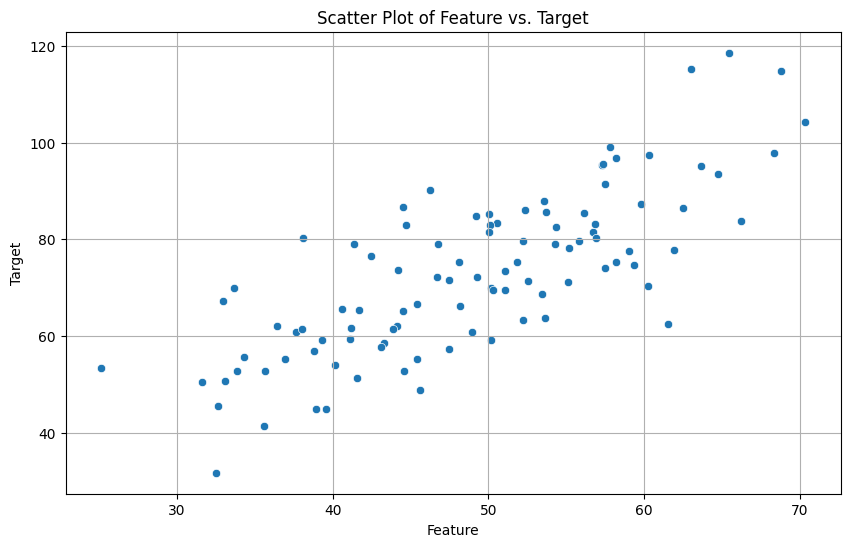

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='feature', y='target', data=df)
plt.title('Scatter Plot of Feature vs. Target')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.grid(True)
plt.show()

In [7]:
df.shape

(100, 2)

In [11]:
num_of_data_points = df.shape[0]
batch_size = 5
num_of_batches = num_of_data_points // batch_size
num_of_epochs = 100

y = wx + b

Loss function = Mean squared error

MSE = (prediction - real)**2/N
    = (wx + b - y)**2/N

Gradient of loss w.r.t w = 2 * x * (wx + b -y) / N

Gradient of loss w.r.t b = 2 * (wx + b - y) / N



In [12]:
w = 0
b = 0

def forward(x):
  return w * x + b

def l_grad_w(x, y):
  return 2*x*(forward(x) - y)

def l_grad_b(x, y):
  return 2*(forward(x) - y)

learning_rate = 0.0001

for epoch in range(num_of_epochs):
  for i in range(num_of_batches):
    x = df['feature'][i*batch_size : (i + 1)*batch_size]
    y = df['target'][i*batch_size : (i + 1)*batch_size]
    w_grad = sum([l_grad_w(x, y) for x, y in zip(x, y)]) / batch_size
    b_grad = sum([l_grad_b(x, y) for x, y in zip(x, y)]) / batch_size
    w -= learning_rate * w_grad
    b -= learning_rate * b_grad

  print(w, b)

1.583250450941673 0.03141327158264103
1.5832307502414935 0.032483759172739456
1.583209751160553 0.0335540595709523
1.583188755261334 0.03462419774570824
1.5831677625444247 0.035694173721615645
1.583146773009342 0.03676398752325872
1.5831257866556043 0.0378336391752179
1.5831048034827289 0.038903128702069925
1.5830838234902338 0.039972456128387776
1.5830628466776375 0.041041621478740735
1.5830418730444573 0.042110624777694367
1.5830209025902116 0.043179466049810496
1.5829999353144186 0.04424814531964723
1.5829789712165965 0.045316662611758936
1.5829580102962637 0.046385017950696286
1.5829370525529385 0.04745321136100622
1.5829160979861394 0.048521242867231966
1.5828951465953849 0.04958911249391302
1.5828741983801935 0.05065682026558517
1.5828532533400843 0.05172436620678046
1.5828323114745757 0.052791750342027245
1.5828113727831865 0.05385897269585016
1.5827904372654358 0.054926033292770106
1.5827695049208426 0.05599293215730426
1.5827485757489257 0.05705966931396611
1.5827276497492042 

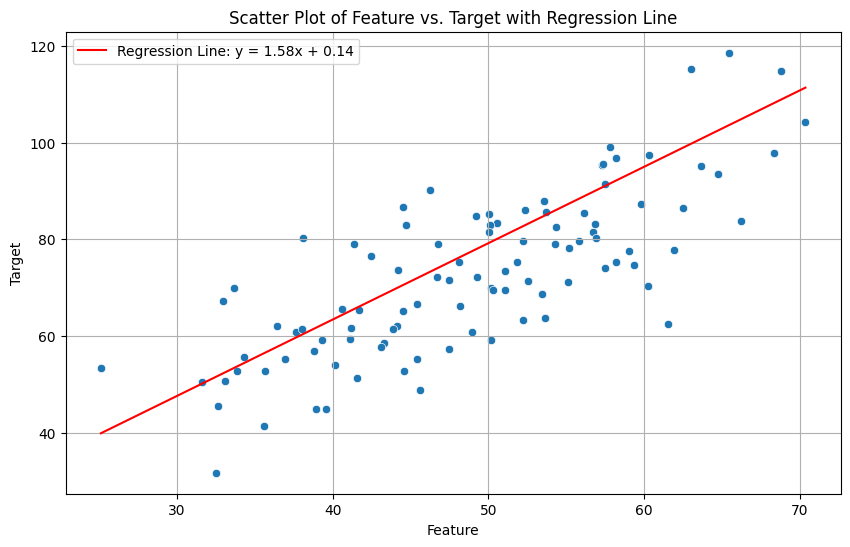

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='feature', y='target', data=df)
plt.title('Scatter Plot of Feature vs. Target with Regression Line')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.grid(True)

# Generate x values for the regression line based on the feature range
x_line = np.linspace(df['feature'].min(), df['feature'].max(), 100)

# Calculate corresponding y values using the learned w and b
y_line = w * x_line + b

# Plot the regression line
plt.plot(x_line, y_line, color='red', label=f'Regression Line: y = {w:.2f}x + {b:.2f}')
plt.legend()
plt.show()